# CHAPTER 5: PHÂN TÍCH KỸ THUẬT VÀ XÂY DỰNG BẢNG ĐIỀU KHIỂN

## Bollinger Bands

### 1. Nhập thư viện:

In [130]:
import pandas as pd
import yfinance as yf
import talib
import matplotlib.pyplot as plt

### 2. Tải giá cổ phiếu của IBM năm 2020:

In [131]:
df = yf.download(
    "IBM",
    start="2020-01-01",
    end="2020-12-31",
    progress=False,
    auto_adjust=True
)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

close = df["Close"].astype(float).to_numpy()

### 3. Tính toán và vẽ biểu đồ trung bình động đơn giản (SMA):

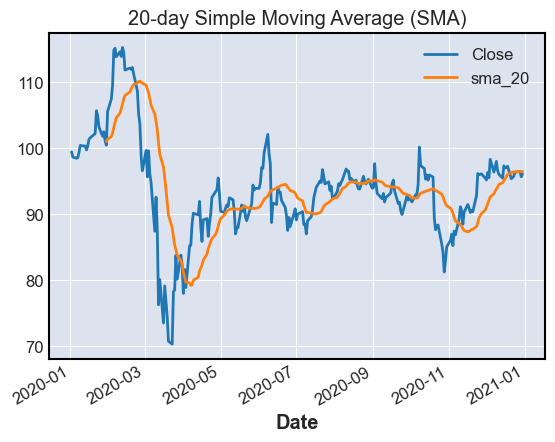

In [132]:
df["sma_20"] = talib.SMA(close, timeperiod=20)
pd.DataFrame({"Close": df["Close"].squeeze(), "sma_20": df["sma_20"]}).plot(
    title="20-day Simple Moving Average (SMA)"
)
plt.show()

### 4. Tính toán và vẽ đồ thị Bollinger Bands:

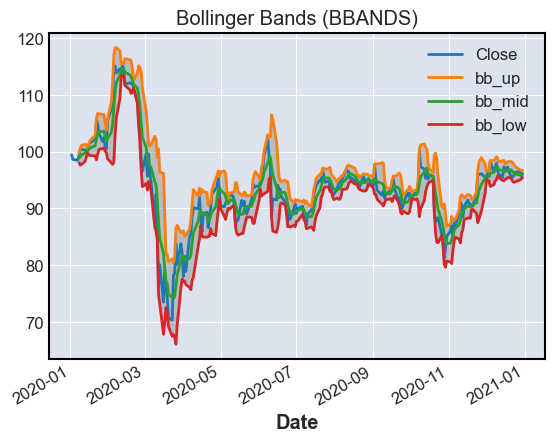

In [133]:
bb_up, bb_mid, bb_low = talib.BBANDS(close)

df["bb_up"] = bb_up
df["bb_mid"] = bb_mid
df["bb_low"] = bb_low

plot_df = pd.DataFrame({
    "Close": df["Close"].squeeze(),
    "bb_up": df["bb_up"],
    "bb_mid": df["bb_mid"],
    "bb_low": df["bb_low"]
}, index=df.index)

fig, ax = plt.subplots()
plot_df.plot(ax=ax, title="Bollinger Bands (BBANDS)")
ax.fill_between(
    plot_df.index,
    plot_df["bb_low"].to_numpy(),
    plot_df["bb_up"].to_numpy(),
    alpha=0.4,
    color="gray"
)
plt.show()

### 5. Tính toán và vẽ đồ thị RSI

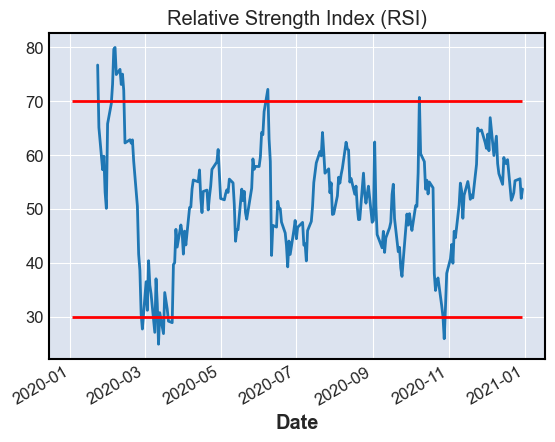

In [134]:
df["rsi"] = talib.RSI(close)

fig, ax = plt.subplots()
df["rsi"].plot(ax=ax, title="Relative Strength Index (RSI)")
ax.hlines(y=30, xmin=df.index.min(), xmax=df.index.max(), colors="red")
ax.hlines(y=70, xmin=df.index.min(), xmax=df.index.max(), colors="red")
plt.show()

### 6. Tính toán và vẽ biểu đồ MACD:

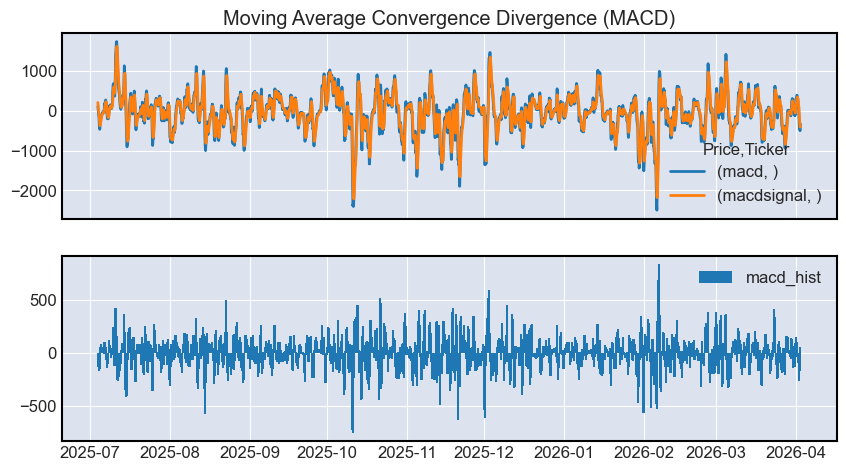

In [161]:
df["macd"], df["macdsignal"], df["macdhist"] = talib.MACD(
    close,
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

df[["macd", "macdsignal"]].plot(
    ax=ax[0],
    title="Moving Average Convergence Divergence (MACD)"
)

ax[1].bar(df.index, df["macdhist"].values, label="macd_hist")
ax[1].legend()
plt.show()

## Thư viện `ta`

### 1. Nhập thư viện

In [136]:
from ta import add_all_ta_features

### 2. Loại bỏ các chỉ số đã tính toán trước đó và chỉ giữ lại các cột cần thiết:

In [137]:
df = df[["Open", "High", "Low", "Close", "Volume"]].copy()

### 3. Tính toán tất cả các chỉ báo kỹ thuật có sẵn trong thư viện `ta`

In [138]:
df = add_all_ta_features(df, open="Open", high="High", low="Low", close="Close", volume="Volume")

## Tải chỉ số RSI được tính toán cho cổ phiếu IBM từ Alpha Vantage

### 1. Nhập thư viện:

In [139]:
from alpha_vantage.techindicators import TechIndicators

### 2. Khởi tạo lớp TechIndicators và xác thực:

In [140]:
API_KEY = "YOUR_ALPHA_VANTAGE_API_KEY"
ta_api = TechIndicators(key=API_KEY, output_format="pandas")

### 3. Tải xuống chỉ số RSI cho cổ phiếu IBM:

In [141]:
rsi_df, rsi_meta = ta_api.get_rsi(symbol="IBM", time_period=14)

### 4. Vẽ biểu đồ chỉ số RSI đã tải xuống:

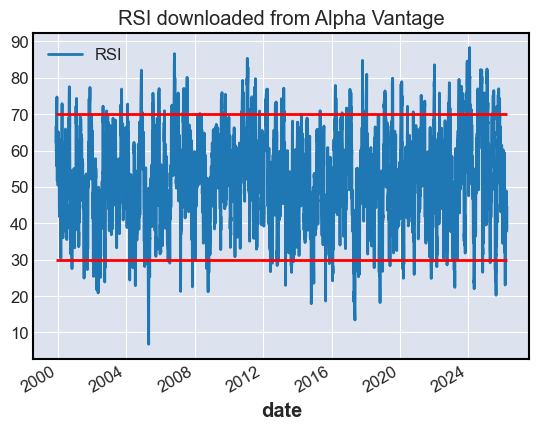

In [142]:
fig, ax = plt.subplots()
rsi_df.plot(ax=ax, 
    title="RSI downloaded from Alpha Vantage")
ax.hlines(y=30, 
    xmin=rsi_df.index.min(), 
    xmax=rsi_df.index.max(), 
    color="red")
ax.hlines(y=70, 
    xmin=rsi_df.index.min(), 
    xmax=rsi_df.index.max(), 
    color="red")

### 5. Khám phá đối tượng siêu dữ liệu:

In [143]:
rsi_meta

{'1: Symbol': 'IBM',
 '2: Indicator': 'Relative Strength Index (RSI)',
 '3: Last Refreshed': '2026-04-01',
 '4: Interval': 'daily',
 '5: Time Period': 14,
 '6: Series Type': 'close',
 '7: Time Zone': 'US/Eastern Time'}

## Tải MACD bằng API của Intrinio

### 1. Nhập thư viện:

In [144]:
import intrinio_sdk as intrinio
import pandas as pd

### 2. Xác thực bằng khóa API cá nhân và Chọn API:

In [145]:
INTRINIO_API_KEY = "YOUR_API_KEY_HERE"
intrinio.ApiClient().set_api_key(INTRINIO_API_KEY)
security_api = intrinio.SecurityApi()

### 3. Yêu cầu chỉ báo MACD cho cổ phiếu IBM từ năm 2020:

In [146]:
df["macd"], df["macdsignal"], df["macdhist"] = talib.MACD(
    close,
    fastperiod=12,
    slowperiod=26,
    signalperiod=9
)

### 4. Chuyển đổi kết quả yêu cầu thành DataFrame của pandas:

In [147]:
macd_df = df[["macd", "macdsignal", "macdhist"]].copy()
macd_df.columns = ["macd_line", "signal_line", "macd_histogram"]
macd_df.index = pd.to_datetime(macd_df.index).date

macd_df.head()

,macd_line,signal_line,macd_histogram
2020-01-02,NaN,NaN,NaN
2020-01-03,NaN,NaN,NaN
2020-01-06,NaN,NaN,NaN
2020-01-07,NaN,NaN,NaN
2020-01-08,NaN,NaN,NaN


### 5. Vẽ biểu đồ MACD:

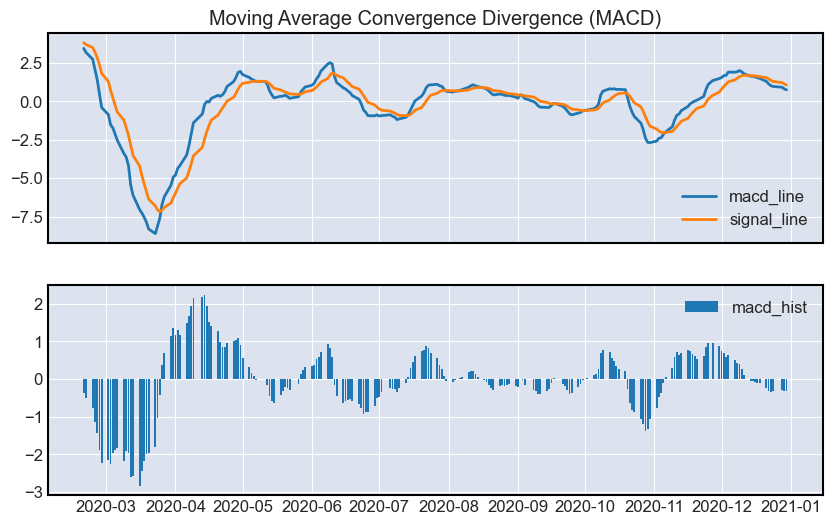

In [148]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

macd_df[["macd_line", "signal_line"]].plot(
    ax=ax[0],
    title="Moving Average Convergence Divergence (MACD)"
)

ax[1].bar(macd_df.index, macd_df["macd_histogram"].values, label="macd_hist")
ax[1].legend()

plt.show()

## Xác định mô hình ba đường thẳng trong biểu đồ nến Bitcoin theo giờ:

### 1. Nhập các thư viện:

In [149]:
import pandas as pd 
import yfinance as yf
import talib
import mplfinance as mpf

### 2. Tải xuống giá Bitcoin theo giờ trong 9 tháng qua:

In [150]:
df = yf.download("BTC-USD",
                 period="9mo",
                 interval="1h",
                 progress=False)

### 3. Xác định mô hình ba đường thẳng:

In [151]:
open_ = df["Open"].squeeze().to_numpy()
high = df["High"].squeeze().to_numpy()
low = df["Low"].squeeze().to_numpy()
close = df["Close"].squeeze().to_numpy()

df["3_line_strike"] = talib.CDL3LINESTRIKE(open_, high, low, close)

### 4. Xác định vị trí và vẽ mô hình giảm giá:

In [152]:
df[df["3_line_strike"] == -100].head()

Price,Close,High,Low,Open,Volume,3_line_strike
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
Datetime,,,,,,
2025-08-31 08:00:00+00:00,109011.531250,109025.867188,108710.109375,108710.109375,0,-100
2025-10-31 08:00:00+00:00,110014.437500,110014.437500,109186.039062,109421.992188,0,-100
2025-11-16 02:00:00+00:00,95843.078125,95843.078125,95084.937500,95276.734375,15168929792,-100
2026-01-02 14:00:00+00:00,89565.335938,89990.468750,88506.007812,89290.679688,3307180032,-100
2026-02-11 11:00:00+00:00,67025.023438,67036.039062,66498.437500,66498.437500,593330176,-100


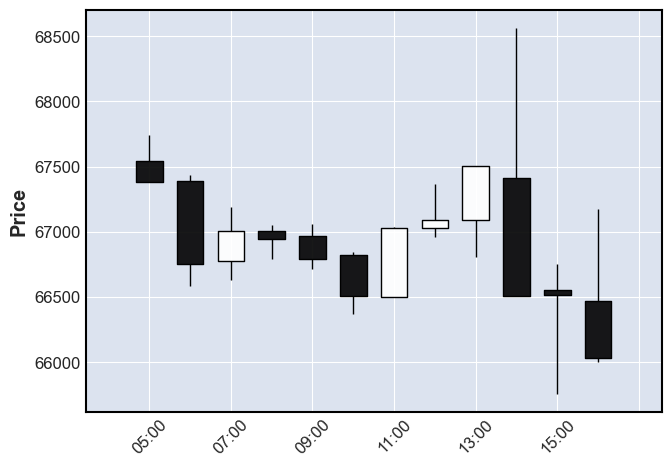

In [153]:
tmp = df["2026-02-11 05:00:00":"2026-02-11 16:00:00"].copy()

if isinstance(tmp.columns, pd.MultiIndex):
    tmp.columns = tmp.columns.get_level_values(0)

for col in ["Open", "High", "Low", "Close", "Volume"]:
    if col in tmp.columns:
        tmp[col] = pd.to_numeric(tmp[col], errors="coerce")

tmp = tmp.dropna(subset=["Open", "High", "Low", "Close"])

mpf.plot(tmp, type="candle")

###  5. Xác định và vẽ biểu đồ mô hình tăng giá:

In [154]:
df[df["3_line_strike"] == 100]

Price,Close,High,Low,Open,Volume,3_line_strike
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
Datetime,,,,,,
2025-08-17 23:00:00+00:00,117454.890625,118033.203125,117454.890625,118033.203125,0,100
2025-08-29 13:00:00+00:00,109151.335938,110754.406250,109033.117188,110742.632812,179478528,100
2025-09-26 14:00:00+00:00,108884.171875,109770.906250,108884.171875,109770.906250,1357930496,100
2025-10-10 14:00:00+00:00,121276.648438,122067.125000,121245.843750,121720.007812,0,100
2025-11-06 05:00:00+00:00,103109.101562,104007.656250,103109.101562,104001.492188,0,100
2025-11-12 14:00:00+00:00,103953.820312,105034.062500,103834.953125,105034.062500,0,100
2026-01-08 02:00:00+00:00,90853.953125,91353.062500,90701.492188,91334.367188,0,100
2026-01-23 14:00:00+00:00,88899.031250,89575.257812,88616.101562,89238.367188,95121408,100


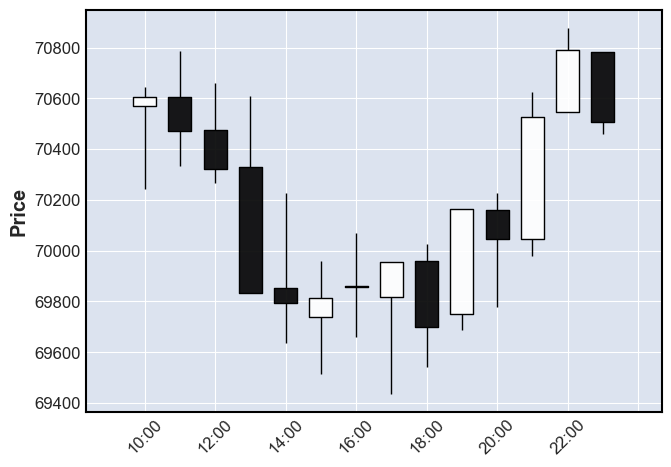

In [155]:
tmp = df["2026-03-20 10:00:00":"2026-03-20 23:00:00"].copy()

if isinstance(tmp.columns, pd.MultiIndex):
    tmp.columns = tmp.columns.get_level_values(0)

for col in ["Open", "High", "Low", "Close", "Volume"]:
    if col in tmp.columns:
        tmp[col] = pd.to_numeric(tmp[col], errors="coerce")

tmp = tmp.dropna(subset=["Open", "High", "Low", "Close"])

mpf.plot(tmp, type="candle")

## Xác định tất cả các mô hình có thể cùng lúc

### 1. Lấy tất cả các tên mô hình có sẵn:

In [156]:
candle_names = talib.get_function_groups()["Pattern Recognition"]

### 2. Lặp lại danh sách các mẫu và cố gắng xác định chúng:

In [157]:
for candle in candle_names:
    df[candle] = getattr(talib, candle)(open_, high, low, close)

### 3. Kiểm tra số liệu thống kê tóm tắt của các mẫu:

In [158]:
with pd.option_context("display.max_rows", len(candle_names)):
    display(df[candle_names].describe().transpose().round(2))

,,count,mean,std,min,25%,50%,75%,max
Price,Ticker,,,,,,,,
CDL2CROWS,,6545.0,-0.05,2.14,-100.0,0.0,0.0,0.0,0.0
CDL3BLACKCROWS,,6545.0,-0.08,2.76,-100.0,0.0,0.0,0.0,0.0
CDL3INSIDE,,6545.0,-0.03,10.34,-100.0,0.0,0.0,0.0,100.0
CDL3LINESTRIKE,,6545.0,0.05,5.10,-100.0,0.0,0.0,0.0,100.0
CDL3OUTSIDE,,6545.0,0.23,23.55,-100.0,0.0,0.0,0.0,100.0
CDL3STARSINSOUTH,,6545.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
CDL3WHITESOLDIERS,,6545.0,0.09,3.03,0.0,0.0,0.0,0.0,100.0
CDLABANDONEDBABY,,6545.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0
CDLADVANCEBLOCK,,6545.0,-1.04,10.14,-100.0,0.0,0.0,0.0,0.0
